# Diferenciación Automática

### CAPÍTULO 3

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

In [11]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors

import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


# Pausa: el problema oculto de las diferencias finitas

## Una pregunta aparentemente trivial

Acabamos de ver que la derivada de $\mathcal{L}$ se puede aproximar por

$$D_+(h) = \frac{\mathcal{L}(x_0 + h) - \mathcal{L}(x_0)}{h}$$

La expansión de Taylor nos dice que $D_+(h) = \mathcal{L}'(x_0) + O(h)$. Es decir: **a $h$ más pequeño, mejor aproximación**.

> Si esto es cierto, ¿por qué no tomar $h = 10^{-16}$ y obtener la derivada con precisión casi perfecta?

Vamos a probarlo experimentalmente con nuestra función conocida:

$$\mathcal{L}(x) = (x^2 + 3x)\sin(x), \qquad x_0 = 2$$

Conocemos la respuesta exacta:

$$\mathcal{L}'(2) = 7\sin(2) + 10\cos(2) \approx 2.2036136223083478$$

## Dos errores que compiten

En realidad, $D_+(h)$ no solo carga error de truncamiento. Cada evaluación de $\mathcal{L}$ en la máquina tiene un error relativo del orden de $\epsilon_{\text{mach}} \approx 2.2 \times 10^{-16}$ (doble precisión IEEE 754). Cuando restamos $\mathcal{L}(x_0+h) - \mathcal{L}(x_0)$, si $h$ es muy pequeño los dos números son casi iguales y la resta **pierde dígitos significativos** — es la *cancelación catastrófica*.

Esto produce un segundo error que crece cuando $h$ disminuye:

$$\text{error total} \;\approx\; \underbrace{\frac{|\mathcal{L}''(x_0)|}{2}\,h}_{\text{truncamiento, crece con }h} \;+\; \underbrace{\frac{2|\mathcal{L}(x_0)|\,\epsilon_{\text{mach}}}{h}}_{\text{redondeo, crece con }1/h}$$

Minimizando: existe un $h^*$ óptimo, y vale aproximadamente

$$h^*_{\text{fwd}} \;\sim\; \sqrt{\epsilon_{\text{mach}}} \;\approx\; 10^{-8}$$

Más allá de ese punto, **bajar $h$ empeora la aproximación**.

## El experimento

Barremos $h$ desde $1$ hasta $10^{-16}$ y graficamos el error absoluto en escala log-log. Probamos también diferencias centradas:

$$D_c(h) = \frac{\mathcal{L}(x_0+h) - \mathcal{L}(x_0-h)}{2h} = \mathcal{L}'(x_0) + O(h^2)$$

Como el truncamiento de centered es $O(h^2)$ en lugar de $O(h)$, el $h$ óptimo cambia:

$$h^*_{\text{cen}} \;\sim\; \epsilon_{\text{mach}}^{1/3} \;\approx\; 6 \times 10^{-6}$$

## Lo que vamos a ver

Una gráfica con forma de **V**:

- **Rama izquierda** (truncamiento dominante): la curva baja con la pendiente predicha por Taylor — pendiente 1 para forward, pendiente 2 para centered. Validar la teoría.
- **Mínimo**: el $h^*$ óptimo. Forward llega como mucho a error $\sim \sqrt{\epsilon_{\text{mach}}} \approx 10^{-8}$. **Perdemos la mitad de los dígitos de la máquina**, incluso eligiendo $h$ de manera óptima.
- **Rama derecha** (redondeo dominante): la curva sube con pendiente $-1$, idéntica para ambos esquemas — porque la cancelación catastrófica no depende del orden del método.

## Por qué esto importa

Tres lecciones que motivan el resto de la clase:

1. **Diferencias finitas tiene un piso de error**: $\sqrt{\epsilon_{\text{mach}}}$ para forward, $\epsilon_{\text{mach}}^{2/3}$ para centered. Nunca llegamos a precisión de máquina.

2. **El $h$ "obvio" es el equivocado**: la intuición de "más pequeño es mejor" falla. Hay que conocer la teoría para elegir bien.

3. **Autodiff no sufre este problema**: aplica derivadas exactas en cada operación elemental. El único error es el de redondeo de la propia evaluación de $\mathcal{L}$ — recuperamos los $\sim 16$ dígitos que la doble precisión nos da.

> Este es el argumento más fuerte a favor de autodiff frente a diferencias finitas: no es solo cuestión de costo, es cuestión de **precisión alcanzable**.

Derivada exacta en x=2: 2.2036136223083478
h* forward (teorico): 2.98e-08
h* centered (teorico): 8.73e-06
Minimo error forward observado: h=6.29e-09, err=2.63e-08
Minimo error centered observado: h=5.35e-07, err=3.65e-11


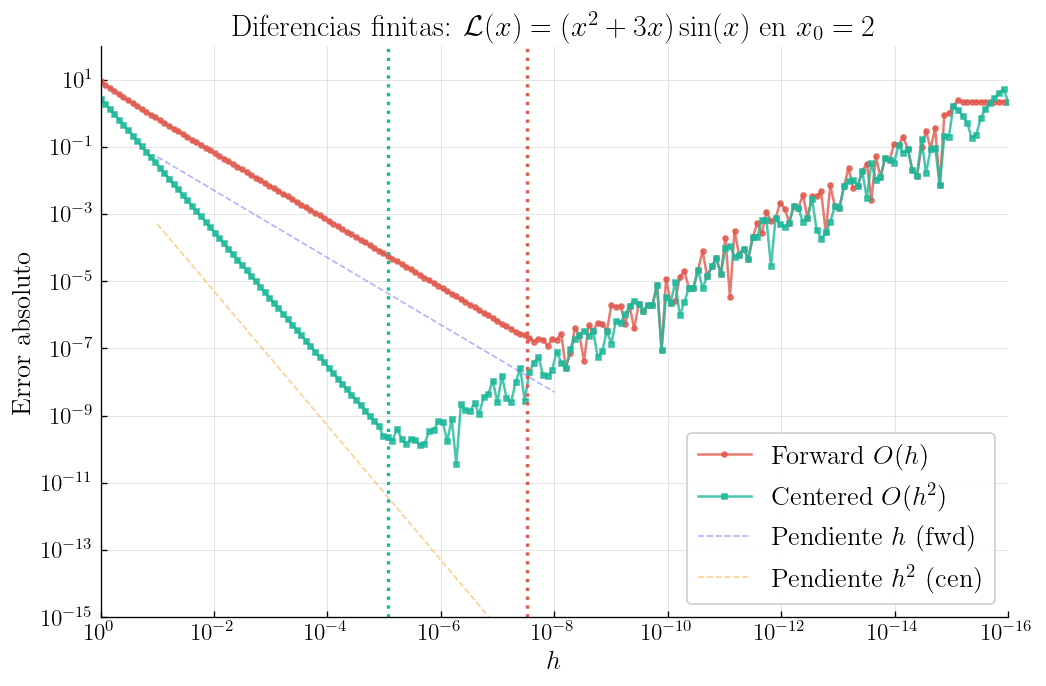

In [27]:
def L(x):
    return (x**2 + 3*x) * np.sin(x)

def L_prime_exact(x):
    return (2*x + 3) * np.sin(x) + (x**2 + 3*x) * np.cos(x)

x0 = 2.0
true_value = L_prime_exact(x0)
print(f"Derivada exacta en x=2: {true_value:.16f}")

# Rango de h: desde 1 hasta 1e-16
hs = np.logspace(0, -16, 200)

# Tres esquemas de diferencias finitas
D_forward  = (L(x0 + hs) - L(x0)) / hs
D_backward = (L(x0) - L(x0 - hs)) / hs
D_centered = (L(x0 + hs) - L(x0 - hs)) / (2 * hs)

err_fwd  = np.abs(D_forward  - true_value)
err_bwd  = np.abs(D_backward - true_value)
err_cen  = np.abs(D_centered - true_value)

# h optimo teorico
eps = np.finfo(float).eps
L_pp = -L(x0)  # segunda derivada aprox (no critica, solo para escala)
M = abs(L(x0))
h_star_fwd = np.sqrt(4 * M * eps / max(abs(L_pp), 1.0))
h_star_cen = (3 * M * eps / max(abs(L_pp), 1.0))**(1/3)
print(f"h* forward (teorico): {h_star_fwd:.2e}")
print(f"h* centered (teorico): {h_star_cen:.2e}")
print(f"Minimo error forward observado: h={hs[np.argmin(err_fwd)]:.2e}, err={err_fwd.min():.2e}")
print(f"Minimo error centered observado: h={hs[np.argmin(err_cen)]:.2e}, err={err_cen.min():.2e}")

# Grafica
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(hs, err_fwd, 'o-', ms=3, color='#E05A4E', label='Forward $O(h)$', alpha=0.8)
ax.loglog(hs, err_cen, 's-', ms=3, color='#1DB89A', label='Centered $O(h^2)$', alpha=0.8)

# Lineas de referencia: pendientes teoricas
h_ref = np.logspace(-1, -8, 50)
ax.loglog(h_ref, 0.5 * h_ref, '--', color='#6C63FF', alpha=0.5, lw=1, label='Pendiente $h$ (fwd)')
ax.loglog(h_ref, 0.05 * h_ref**2, '--', color='#F4A623', alpha=0.5, lw=1, label='Pendiente $h^2$ (cen)')

# h* optimos
ax.axvline(h_star_fwd, color='#E05A4E', alpha=1, ls=':', lw=2)
ax.axvline(h_star_cen, color='#1DB89A', alpha=1, ls=':', lw=2)


ax.set_xlabel(r'$h$')
ax.set_ylabel(r'Error absoluto')
ax.set_title(r'Diferencias finitas: $\mathcal{L}(x)=(x^2+3x)\sin(x)$ en $x_0=2$')
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(True, which='both', alpha=0.3, ls='-', lw=0.4)
ax.set_xlim(1e-16, 1)
ax.set_ylim(1e-15, 1e2)
ax.invert_xaxis()  # h decrece hacia la derecha (intuicion: "mas preciso")

plt.tight_layout()
plt.show()